In [1]:
import json
import seaborn as sns

from frapppe import MFA
from frapppe.utils import plot_fluxes, plot_mdvs_boxplots


sns.set_theme()

def read_config(path_to_file):
    with open(path_to_file) as fh:
        return json.load(fh)


In [2]:
bounds = {
    "lower": 0,
    "upper": 100,
    "glk": [10, 10],
    "co2in": [90, 100],
    "co2out": [0, 100],
    "URIin": [0, 10]
}

target_emus = {
    "G6P": "123456",
    "F6P": "123456",
    "Pyr": "123",
    "Mal": "1234",
    "S7P": "1234567",
    "Cit": "123456",
    "Suc": "1234",
    "Fum": "1234",
    "Val": "12345",
    "Gln": "12345",
    "Arg": "123456",
    "Thr": "1234",
    "Met": "12345",
    "Asp": "1234",
    "Asn": "1234",
    "Ser": "123",
    "Phe": "123456789",
    "Tyr": "123456789",
    "Pro": "12345",
    "Leu": "123456",
    "Lys": "123456",
    "R1P": "12345",
    "RIB": "12345",
    "R5P": "12345",
    "PRPP": "12345",
    "CO2": "1",
    "OAA": "1234",
    "Trp": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "URA": "1234",
    "URI": "123456789",
    "UMP": "123456789"
}

labelling = {
    "labeled_substrate": "Glc.ex", 
    "labeling_pattern": ["111111"], 
    "percentage": [1], 
    "purity": [0.994]    
}

In [3]:
model_path = "buniformis_example_model.tsv"
mfa = MFA(model_path)

In [4]:
df_fluxes = mfa.sample_fluxes(10000, bounds=bounds, thinning=1000)
df_fluxes

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
pgi_f,10.911961,11.661677,12.675856,12.168658,12.534479,13.844836,14.930234,16.218620,15.384440,13.715257,...,50.398061,50.967581,49.799050,49.814123,49.201310,47.903389,48.724718,48.896345,49.232285,50.969719
pgi_b,2.473761,2.057759,3.555024,3.247024,4.691805,4.462199,5.976188,7.536557,7.127498,7.109943,...,42.786268,41.597683,40.390336,39.983654,39.350917,39.495264,39.121795,39.367522,40.465641,41.923190
pfk,11.594507,11.759326,11.634234,10.720076,10.477029,11.431463,12.304804,12.556097,12.316719,11.882323,...,12.955572,13.098329,13.728651,14.695386,14.097160,14.085233,14.301311,13.995157,12.836217,13.196429
fba_f,12.280608,11.876755,11.866188,14.291063,15.084746,16.142669,15.806871,14.964893,13.078800,12.532948,...,50.248987,49.432420,51.549024,53.171731,52.401013,52.882695,53.177877,53.461323,54.599853,53.133688
fba_b,0.686101,0.117429,0.231954,3.570987,4.607717,4.711205,3.502067,2.408796,0.762081,0.650625,...,37.293414,36.334091,37.820373,38.476345,38.303854,38.797462,38.876566,39.466166,41.763636,39.937259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URIH,8.644712,8.003101,9.175307,9.646485,8.333299,8.636532,6.894565,5.928730,5.649119,5.820214,...,2.147053,1.041304,0.532524,3.085001,4.810752,5.456784,7.220791,7.578967,7.406031,6.733542
URIDK,0.236482,0.578517,0.595705,0.168857,0.274585,1.831568,0.287059,0.169488,0.102319,0.529615,...,0.260099,0.586198,1.404680,0.263187,0.158486,0.018776,0.149420,0.067596,1.034078,0.245400
PPM_f,8.602060,12.858235,17.932883,22.027121,23.308542,23.190899,30.310030,32.769521,36.962109,37.399728,...,71.159247,69.039637,65.069703,62.989071,63.926579,64.101812,63.211686,66.143944,64.545128,65.894291
PPM_b,8.264299,12.332151,17.765552,21.796897,22.327380,23.159802,28.257965,30.932516,33.650203,33.891613,...,63.776513,61.611735,57.661410,56.393582,59.929051,58.713245,61.404122,65.232811,63.631462,64.098532


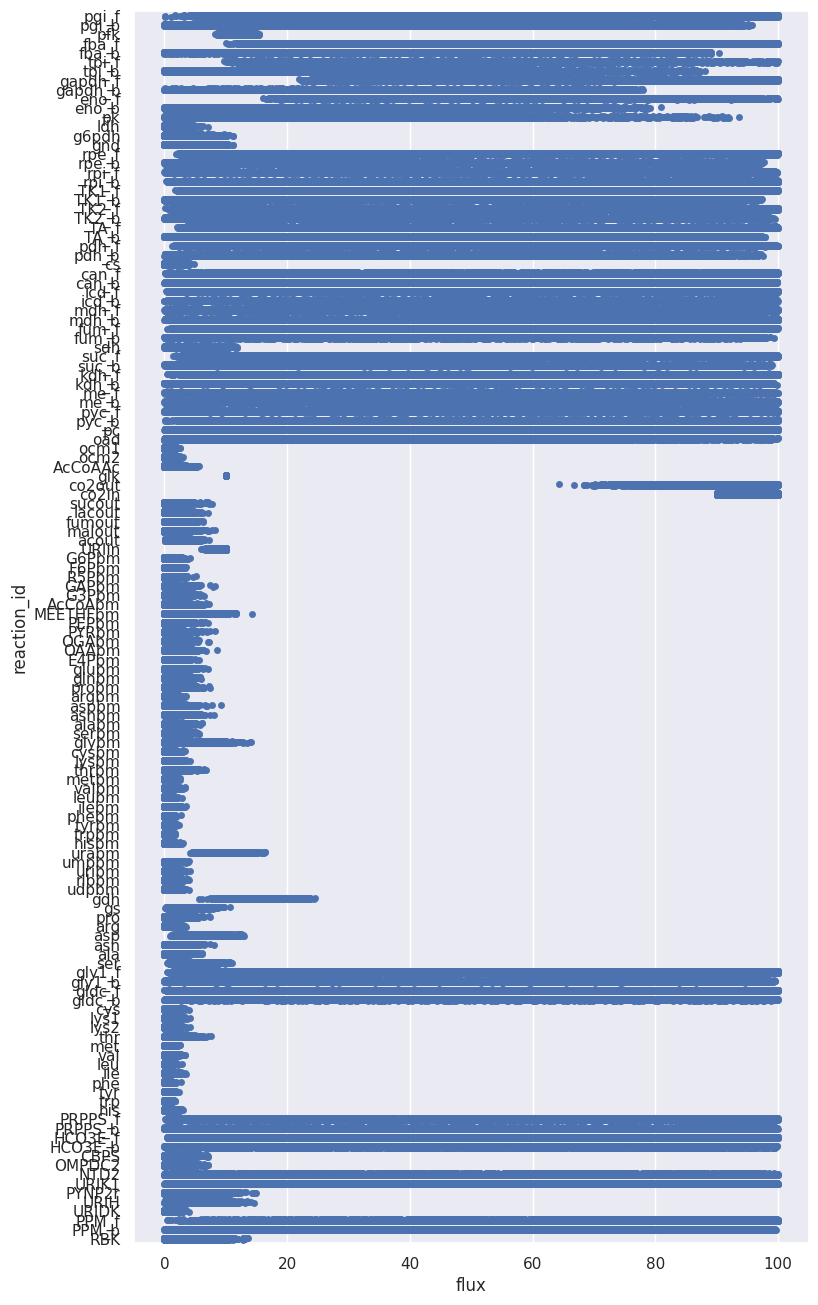

In [5]:
fig = plot_fluxes(df_fluxes)

In [6]:
df_mdvs = mfa.simulate_mdvs(df_fluxes.iloc[:, :10], target_emus, labelling, parallel=4, copy=False)
df_mdvs

,0,1,2,3,4,5,6,7,8,9
Arg_123456_0,0.185005,0.170328,0.190494,0.225814,0.180840,0.223234,0.242329,0.228080,0.171543,0.166188
Arg_123456_1,0.078014,0.067162,0.084956,0.091910,0.092236,0.108776,0.100567,0.103761,0.126640,0.114688
Arg_123456_2,0.138613,0.124023,0.140702,0.107344,0.118209,0.111890,0.099231,0.068959,0.166476,0.168169
Arg_123456_3,0.440294,0.489409,0.426539,0.456635,0.473040,0.447941,0.456386,0.476686,0.366852,0.352999
Arg_123456_4,0.143161,0.135321,0.140690,0.108967,0.124157,0.100221,0.094641,0.113182,0.147249,0.169091
...,...,...,...,...,...,...,...,...,...,...
Val_12345_1,0.011584,0.010008,0.012595,0.020372,0.021732,0.029199,0.024321,0.026084,0.030450,0.024448
Val_12345_2,0.225017,0.207347,0.238608,0.228717,0.202262,0.220109,0.230147,0.208392,0.226921,0.225376
Val_12345_3,0.187523,0.166452,0.181529,0.211702,0.201374,0.230737,0.225534,0.238738,0.223499,0.222690
Val_12345_4,0.090564,0.125856,0.114358,0.084165,0.106947,0.080363,0.071954,0.051065,0.086882,0.074046


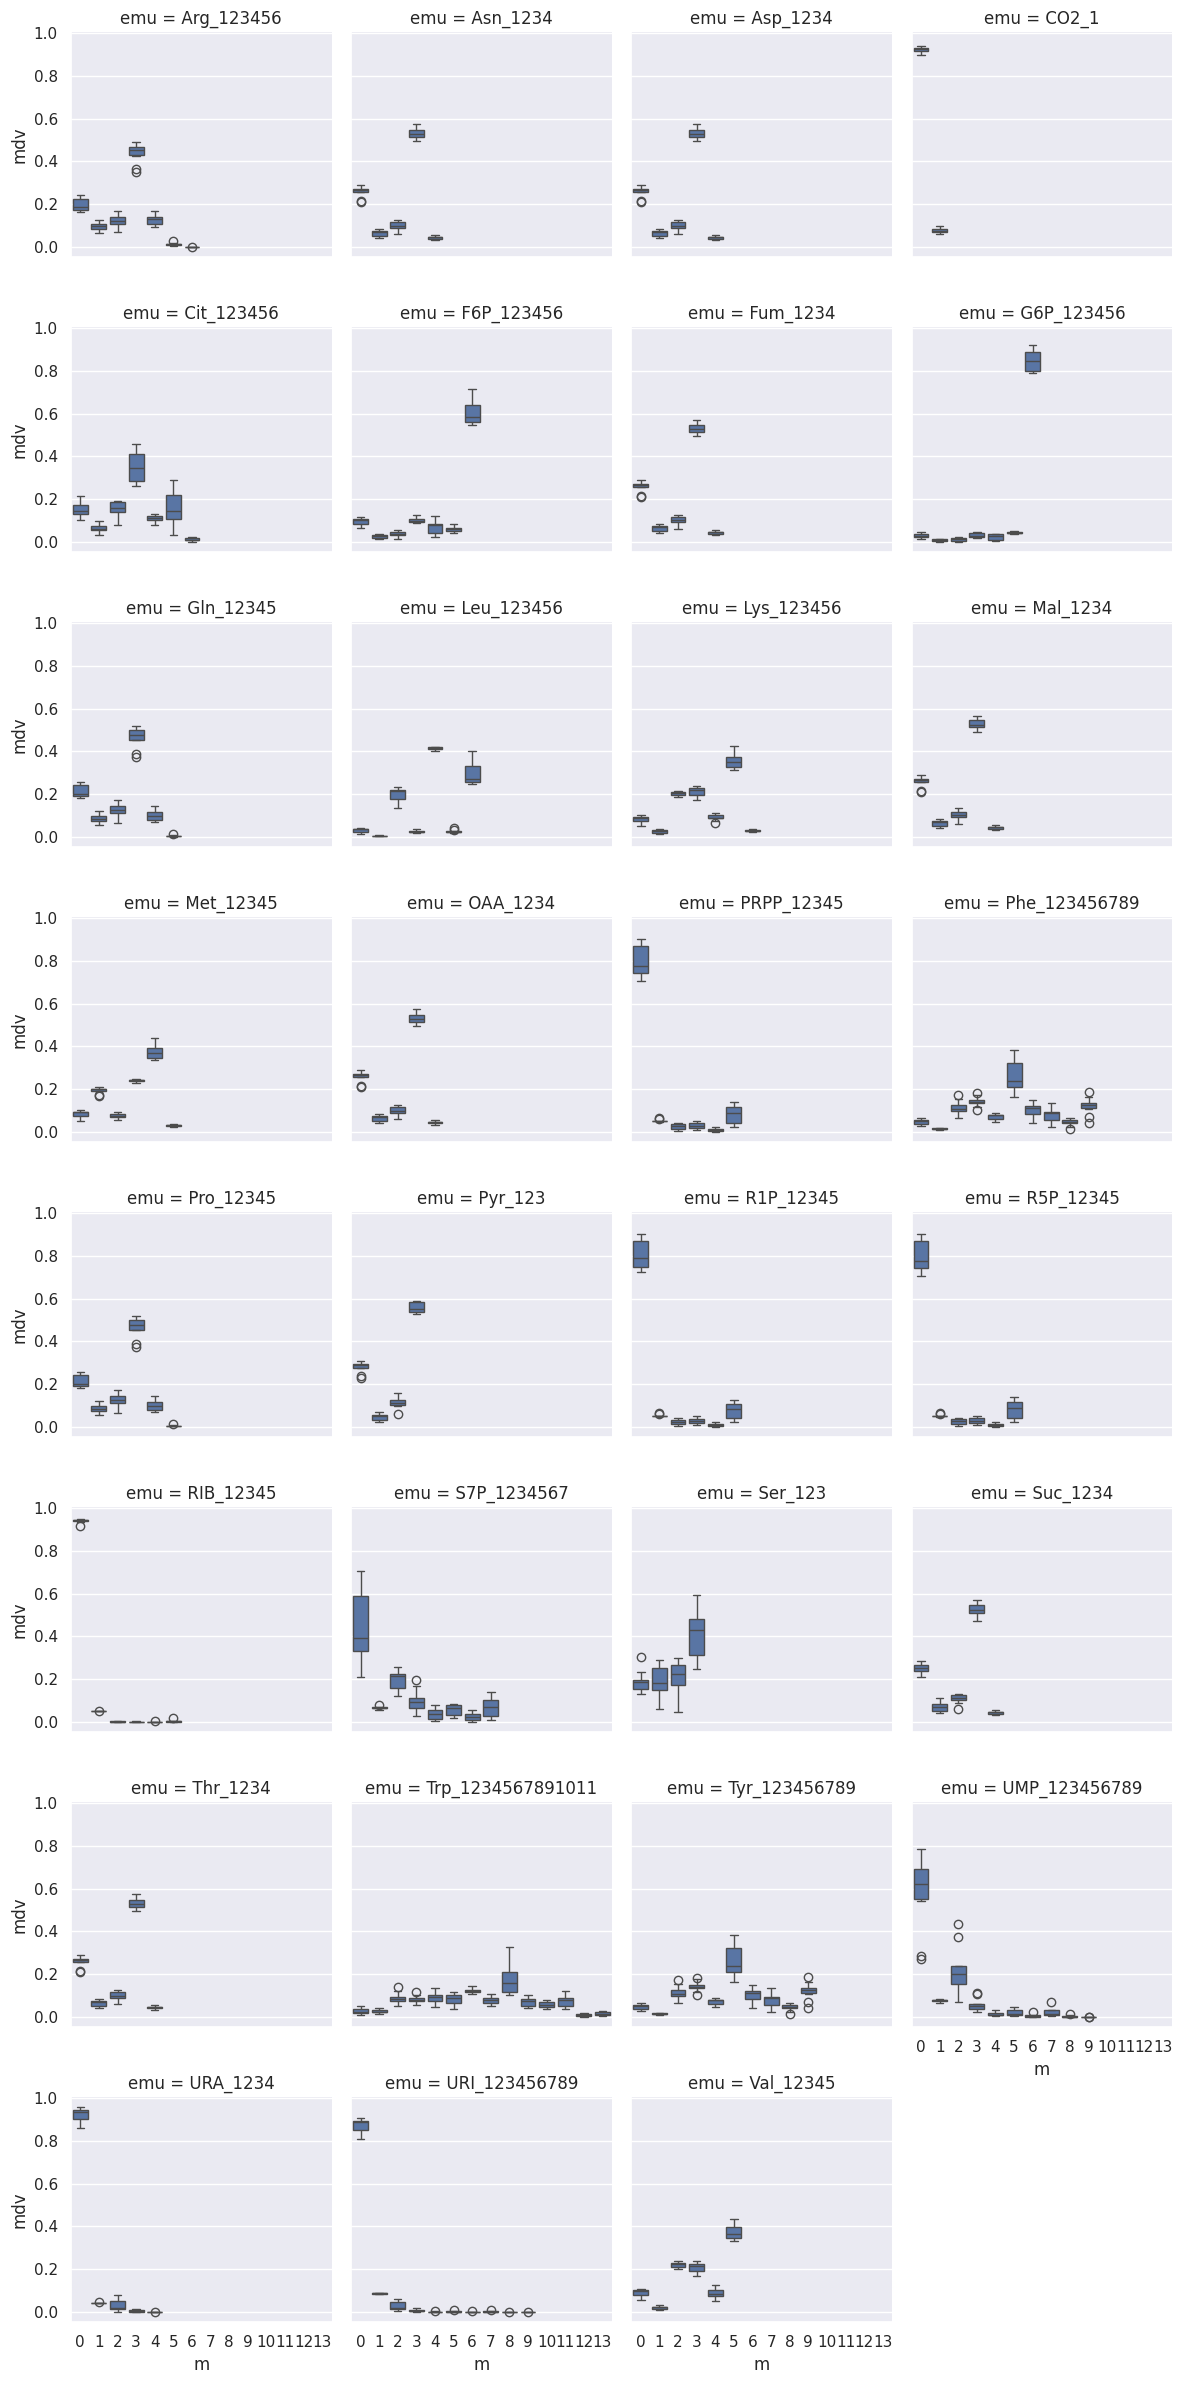

In [7]:
fg = plot_mdvs_boxplots(df_mdvs)